# Paso 1: Obtener y cargar los datos

In [1]:
import pandas as pd

df = pd.read_csv('world-data-2023.csv')  # ajusta el nombre exacto del archivo
print(df.shape)
df.head()

(195, 35)


,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    str    
 1   Density
(P/Km2)                            195 non-null    str    
 2   Abbreviation                               188 non-null    str    
 3   Agricultural Land( %)                      188 non-null    str    
 4   Land Area(Km2)                             194 non-null    str    
 5   Armed Forces size                          171 non-null    str    
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    str    
 9   Co2-Emissions                              188 non-null    str    
 10  CPI                                  

In [3]:
# Vista rápida de cómo vienen formateadas las columnas numéricas (para confirmar la sospecha de $ y % como texto)
df.select_dtypes(include='object').head()

C:\Users\uriel\AppData\Local\Temp\ipykernel_31284\927525589.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').head()


,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Capital/Major City,Co2-Emissions,CPI,CPI Change (%),...,Largest city,Minimum wage,Official language,Out of pocket health expenditure,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,60,AF,58.10%,"652,230","323,000",Kabul,"8,672",149.9,2.30%,...,Kabul,$0.43,Pashto,78.40%,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273"
1,Albania,105,AL,43.10%,"28,748","9,000",Tirana,"4,536",119.05,1.40%,...,Tirana,$1.12,Albanian,56.90%,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593"
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",Algiers,"150,006",151.36,2.00%,...,Algiers,$0.95,Arabic,28.10%,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
3,Andorra,164,AD,40.00%,468,NaN,Andorra la Vella,469,NaN,NaN,...,Andorra la Vella,$6.63,Catalan,36.40%,"77,142",NaN,NaN,NaN,NaN,"67,873"
4,Angola,26,AO,47.50%,"1,246,700","117,000",Luanda,"34,693",261.73,17.10%,...,Luanda,$0.71,Portuguese,33.40%,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"


In [4]:
# 1. Limpiar nombres de columnas (quitar \n, espacios extra)
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()
print(df.columns.tolist())

['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)', 'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code', 'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Currency-Code', 'Fertility Rate', 'Forested Area (%)', 'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)', 'Infant mortality', 'Largest city', 'Life expectancy', 'Maternal mortality ratio', 'Minimum wage', 'Official language', 'Out of pocket health expenditure', 'Physicians per thousand', 'Population', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']


In [5]:
# 2. Ver TODAS las columnas de texto para identificar qué patrones de limpieza necesita cada una
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].dropna().head(3).tolist())


Country:
['Afghanistan', 'Albania', 'Algeria']

Density (P/Km2):
['60', '105', '18']

Abbreviation:
['AF', 'AL', 'DZ']

Agricultural Land( %):
['58.10%', '43.10%', '17.40%']

Land Area(Km2):
['652,230', '28,748', '2,381,741']

Armed Forces size:
['323,000', '9,000', '317,000']

Capital/Major City:
['Kabul', 'Tirana', 'Algiers']

Co2-Emissions:
['8,672', '4,536', '150,006']

CPI:
['149.9', '119.05', '151.36']

CPI Change (%):
['2.30%', '1.40%', '2.00%']

Currency-Code:
['AFN', 'ALL', 'DZD']

Forested Area (%):
['2.10%', '28.10%', '0.80%']

Gasoline Price:
['$0.70 ', '$1.36 ', '$0.28 ']

GDP:
['$19,101,353,833 ', '$15,278,077,447 ', '$169,988,236,398 ']

Gross primary education enrollment (%):
['104.00%', '107.00%', '109.90%']

Gross tertiary education enrollment (%):
['9.70%', '55.00%', '51.40%']

Largest city:
['Kabul', 'Tirana', 'Algiers']

Minimum wage:
['$0.43 ', '$1.12 ', '$0.95 ']

Official language:
['Pashto', 'Albanian', 'Arabic']

Out of pocket health expenditure:
['78.40%', '

C:\Users\uriel\AppData\Local\Temp\ipykernel_31284\3700958979.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


escribir una función que detecte automáticamente si una columna de texto es "numérica disfrazada" y la limpie, dejando intactas las verdaderamente categóricas.

In [6]:
import numpy as np

# Columnas que sabemos son categóricas reales (no numéricas, aunque sean texto) — no tocar
columnas_categoricas = ['Country', 'Abbreviation', 'Capital/Major City', 'Currency-Code',
                         'Largest city', 'Official language']

def limpiar_numerico(serie):
    """Intenta limpiar una columna de texto (quitando $, %, comas) y convertirla a float."""
    limpia = (serie.astype(str)
                    .str.replace('$', '', regex=False)
                    .str.replace(',', '', regex=False)
                    .str.replace('%', '', regex=False)
                    .str.strip())
    return pd.to_numeric(limpia, errors='coerce')

columnas_texto = df.select_dtypes(include='object').columns
columnas_a_limpiar = [c for c in columnas_texto if c not in columnas_categoricas]

for col in columnas_a_limpiar:
    df[col] = limpiar_numerico(df[col])

print(df.dtypes)

Country                                          str
Density (P/Km2)                                int64
Abbreviation                                     str
Agricultural Land( %)                        float64
Land Area(Km2)                               float64
Armed Forces size                            float64
Birth Rate                                   float64
Calling Code                                 float64
Capital/Major City                               str
Co2-Emissions                                float64
CPI                                          float64
CPI Change (%)                               float64
Currency-Code                                    str
Fertility Rate                               float64
Forested Area (%)                            float64
Gasoline Price                               float64
GDP                                          float64
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      f

C:\Users\uriel\AppData\Local\Temp\ipykernel_31284\1769355164.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include='object').columns


In [7]:
# Verificación: ¿cuántos valores se volvieron NaN por la conversión (además de los nulos originales)?
# Si el conteo de nulos se disparó mucho, algo no se limpió bien en esa columna específica
print(df[columnas_a_limpiar].isnull().sum().sort_values(ascending=False))

Minimum wage                                 45
Tax revenue (%)                              26
Armed Forces size                            24
Gasoline Price                               20
Population: Labor force participation (%)    19
Unemployment rate                            19
CPI                                          17
CPI Change (%)                               16
Total tax rate                               12
Gross tertiary education enrollment (%)      12
Agricultural Land( %)                         7
Gross primary education enrollment (%)        7
Out of pocket health expenditure              7
Forested Area (%)                             7
Co2-Emissions                                 7
Urban_population                              5
GDP                                           2
Land Area(Km2)                                1
Population                                    1
Density (P/Km2)                               0
dtype: int64


# Paso 3: Selección de features para clustering

In [8]:
# Features candidatas: economía, salud, educación, demografía — evitando duplicar información
features_candidatas = [
    'GDP', 'Minimum wage', 'Unemployment rate', 'Tax revenue (%)',
    'Infant mortality', 'Life expectancy', 'Maternal mortality ratio',
    'Physicians per thousand', 'Out of pocket health expenditure',
    'Fertility Rate', 'Birth Rate',
    'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)',
    'Urban_population', 'Population', 'Population: Labor force participation (%)',
    'Co2-Emissions', 'Forested Area (%)'
]

df_features = df[['Country'] + features_candidatas].copy()
print(df_features.isnull().sum().sort_values(ascending=False))
print("\nShape:", df_features.shape)

Minimum wage                                 45
Tax revenue (%)                              26
Unemployment rate                            19
Population: Labor force participation (%)    19
Maternal mortality ratio                     14
Gross tertiary education enrollment (%)      12
Life expectancy                               8
Forested Area (%)                             7
Fertility Rate                                7
Out of pocket health expenditure              7
Physicians per thousand                       7
Co2-Emissions                                 7
Gross primary education enrollment (%)        7
Infant mortality                              6
Birth Rate                                    6
Urban_population                              5
GDP                                           2
Population                                    1
Country                                       0
dtype: int64

Shape: (195, 19)


In [9]:
# GDP y Population suelen tener escalas muy dispares entre países grandes/pequeños —
# conviene usar PIB per cápita en vez de PIB total, para comparar países de forma justa
df_features['gdp_per_capita'] = df_features['GDP'] / df_features['Population']
df_features['urban_pct'] = df_features['Urban_population'] / df_features['Population'] * 100

print(df_features[['Country', 'GDP', 'Population', 'gdp_per_capita', 'urban_pct']].head(10))

               Country           GDP  Population  gdp_per_capita  urban_pct
0          Afghanistan  1.910135e+10  38041754.0      502.115487  25.753999
1              Albania  1.527808e+10   2854191.0     5352.857411  61.229014
2              Algeria  1.699882e+11  43053054.0     3948.343279  73.189001
3              Andorra  3.154058e+09     77142.0    40886.391162  87.984496
4               Angola  9.463542e+10  31825295.0     2973.591160  66.176999
5  Antigua and Barbuda  1.727759e+09     97118.0    17790.309304  24.506271
6            Argentina  4.496634e+11  44938712.0    10006.148974  91.991001
7              Armenia  1.367280e+10   2957731.0     4622.733493  63.219001
8            Australia  1.392681e+12  25766605.0    54049.828812  84.779334
9              Austria  4.463147e+11   8877067.0    50277.275087  58.515003


In [10]:
# 1. Definimos las features finales, descartando Minimum wage (demasiados nulos) 
# y las columnas ya "consumidas" (GDP, Population, Urban_population → convertidas en ratios)
features_finales = [
    'gdp_per_capita', 'urban_pct', 'Unemployment rate', 'Tax revenue (%)',
    'Infant mortality', 'Life expectancy', 'Maternal mortality ratio',
    'Physicians per thousand', 'Out of pocket health expenditure',
    'Fertility Rate', 'Birth Rate',
    'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)',
    'Population: Labor force participation (%)',
    'Co2-Emissions', 'Forested Area (%)'
]

df_modelo = df_features[['Country'] + features_finales].copy()
print(df_modelo.isnull().sum().sort_values(ascending=False))

Tax revenue (%)                              26
Population: Labor force participation (%)    19
Unemployment rate                            19
Maternal mortality ratio                     14
Gross tertiary education enrollment (%)      12
Life expectancy                               8
Co2-Emissions                                 7
Physicians per thousand                       7
Out of pocket health expenditure              7
Forested Area (%)                             7
Gross primary education enrollment (%)        7
Fertility Rate                                7
Infant mortality                              6
Birth Rate                                    6
urban_pct                                     5
gdp_per_capita                                2
Country                                       0
dtype: int64


In [11]:
# 2. ¿Cuántos países quedarían si eliminamos filas con CUALQUIER nulo? (opción más simple, pero puede perder mucho)
print("Países completos (sin ningún nulo):", df_modelo.dropna().shape[0], "de", df_modelo.shape[0])

Países completos (sin ningún nulo): 154 de 195


In [12]:
# 3. Alternativa: imputar con la mediana (razonable con ~5-20% de nulos por columna, no elimina países)
df_modelo_imputado = df_modelo.copy()
for col in features_finales:
    df_modelo_imputado[col] = df_modelo_imputado[col].fillna(df_modelo_imputado[col].median())

print("Nulos después de imputar:", df_modelo_imputado.isnull().sum().sum())

Nulos después de imputar: 0


# Paso 4: EDA antes de clustering

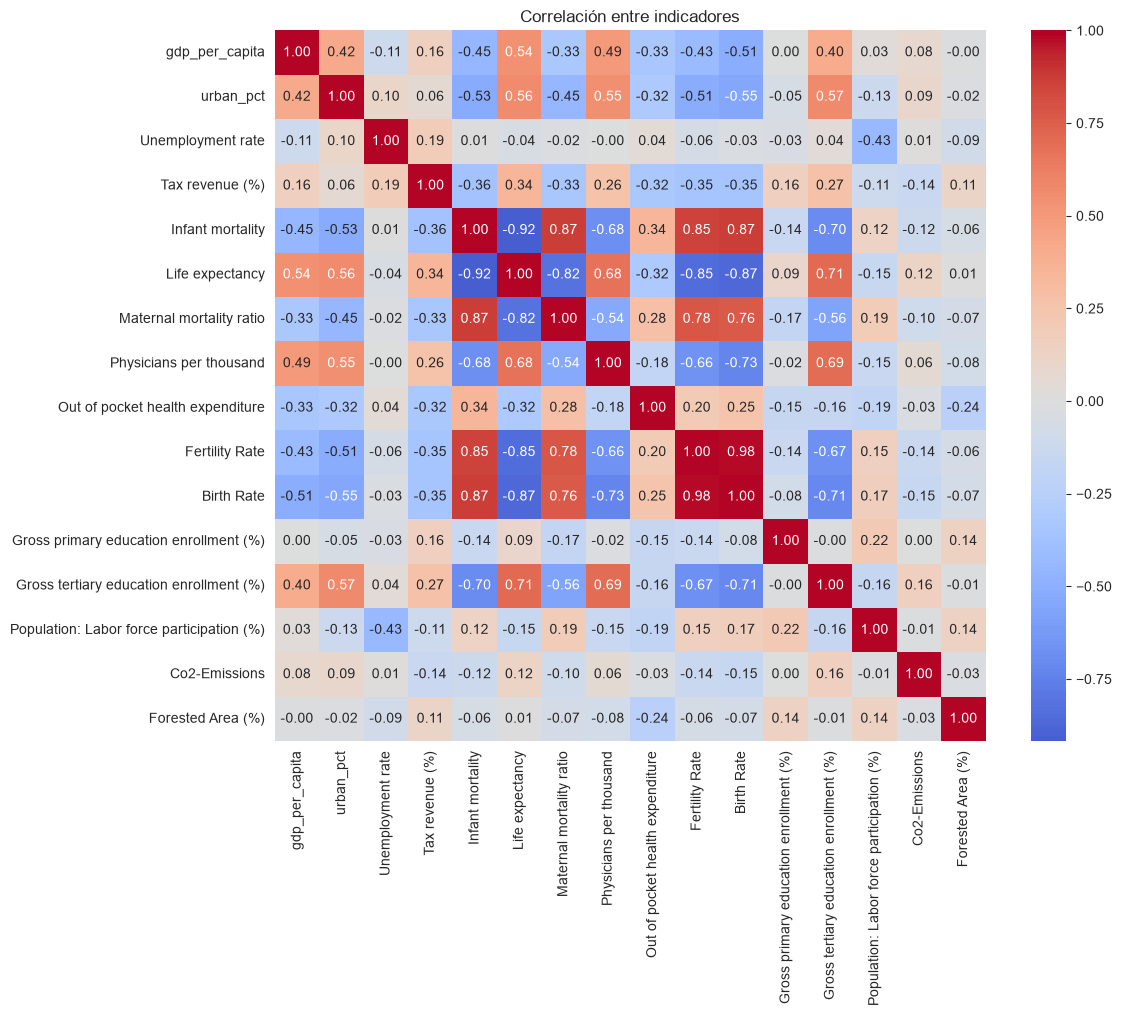

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Matriz de correlación entre features — para detectar redundancia antes de escalar
plt.figure(figsize=(12, 10))
corr = df_modelo_imputado[features_finales].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlación entre indicadores')
plt.tight_layout()
plt.show()

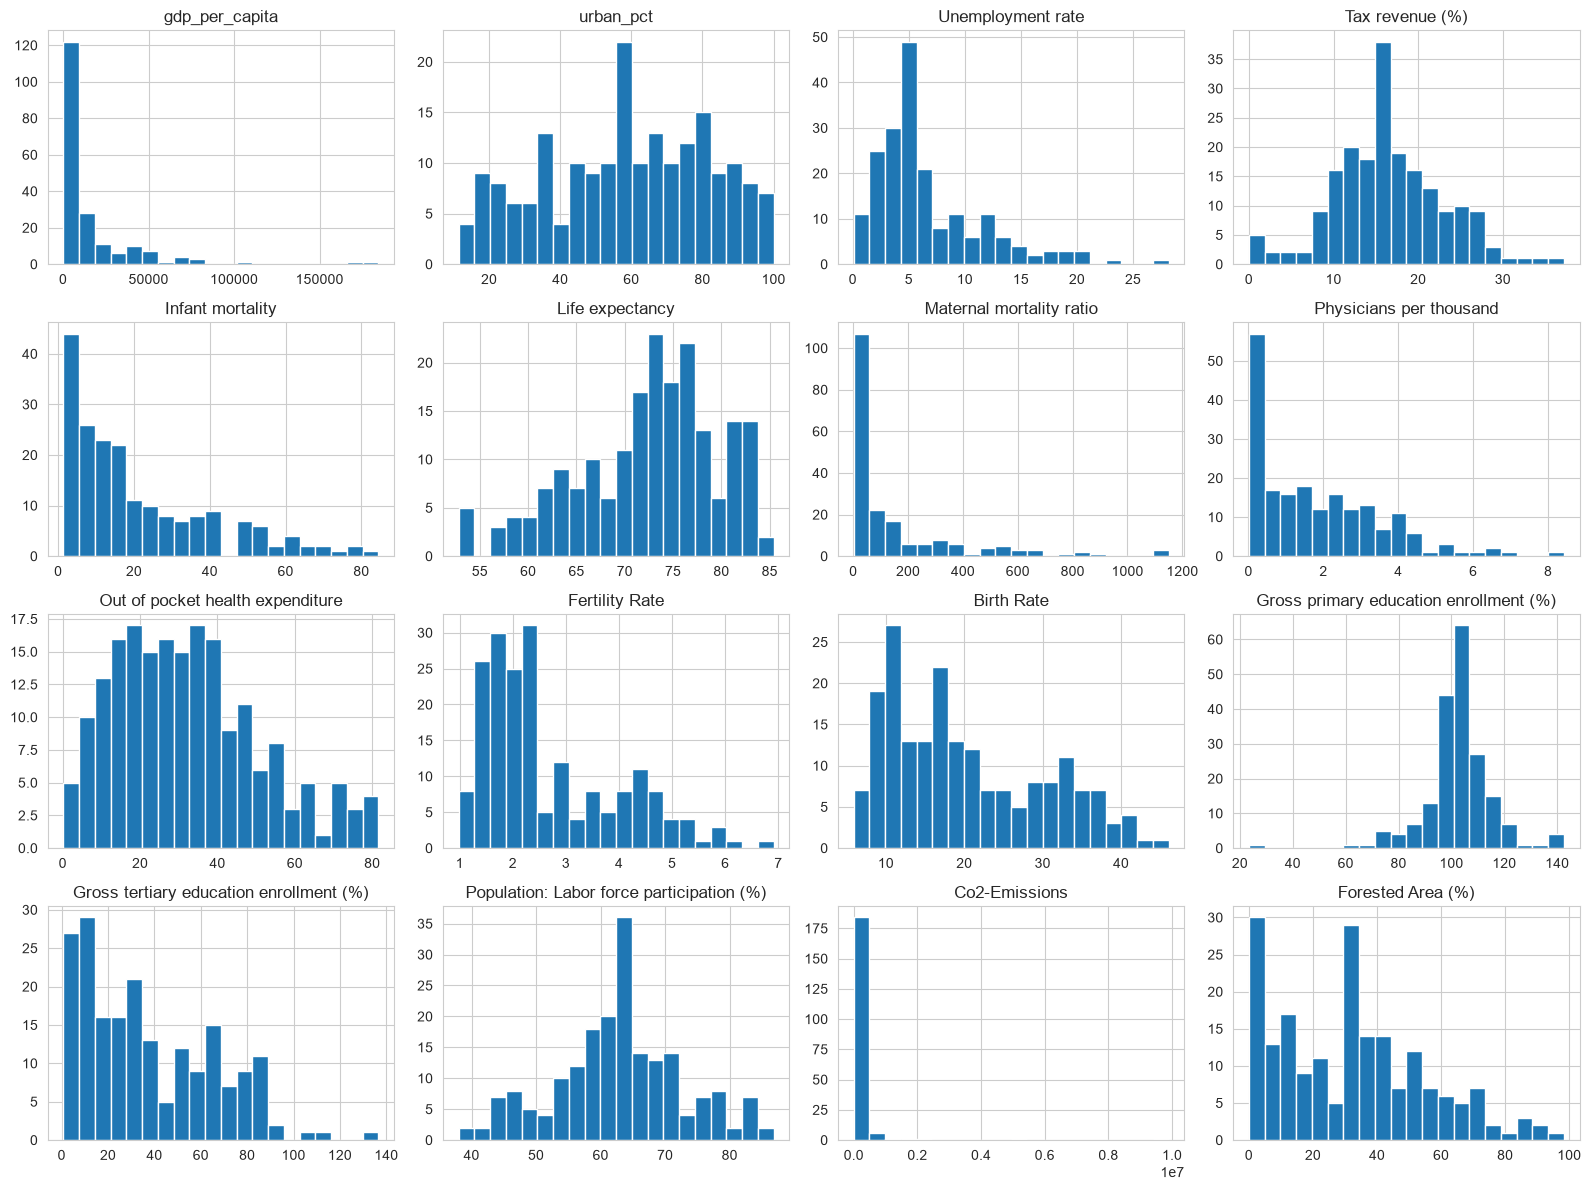

In [14]:
# Distribución de cada feature — para detectar sesgos fuertes antes de escalar
df_modelo_imputado[features_finales].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()

In [15]:
# Estadísticas descriptivas generales
df_modelo_imputado[features_finales].describe()

,gdp_per_capita,urban_pct,Unemployment rate,Tax revenue (%),Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Out of pocket health expenditure,Fertility Rate,Birth Rate,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Population: Labor force participation (%),Co2-Emissions,Forested Area (%)
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,1.950000e+02,195.000000
mean,15591.023213,58.790927,6.737641,16.537436,21.107179,72.317436,152.682051,1.826205,32.567692,2.681872,20.145282,102.473077,37.547179,62.710000,1.718583e+05,32.014872
std,25157.076375,23.024712,4.845382,6.479029,19.285229,7.330019,226.629794,1.655113,18.827087,1.261755,9.798615,12.912165,28.388404,9.975707,8.240967e+05,23.358162
min,261.247473,11.433771,0.090000,0.000000,1.400000,52.800000,2.000000,0.010000,0.200000,0.980000,5.900000,23.400000,0.800000,38.000000,1.100000e+01,0.000000
25%,1953.905106,42.009002,3.590000,12.550000,6.100000,67.450000,16.500000,0.360000,17.700000,1.710000,11.450000,99.350000,12.650000,57.250000,2.625500e+03,11.450000
50%,5955.109010,59.537996,5.360000,16.300000,14.000000,73.200000,53.000000,1.460000,30.700000,2.245000,17.950000,102.550000,31.200000,62.450000,1.230300e+04,32.000000
75%,17339.093482,77.665792,8.840000,20.300000,31.550000,77.250000,175.000000,2.875000,43.750000,3.565000,28.445000,107.550000,61.100000,68.300000,6.194100e+04,47.450000
max,184396.986783,100.000000,28.180000,37.200000,84.500000,85.400000,1150.000000,8.420000,81.600000,6.910000,46.080000,142.500000,136.600000,86.800000,9.893038e+06,98.300000


# Paso 5: Reducir redundancia + transformar sesgo

In [18]:
# 1. Quitar redundancia: nos quedamos con Life expectancy (resume bien mortalidad/fertilidad)
#    y Birth Rate (descartamos Infant mortality y Fertility Rate, correlación >0.85 con otras)
features_finales_v2 = [
    'gdp_per_capita', 'urban_pct', 'Unemployment rate', 'Tax revenue (%)',
    'Life expectancy', 'Physicians per thousand', 'Out of pocket health expenditure',
    'Birth Rate',
    'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)',
    'Population: Labor force participation (%)',
    'Co2-Emissions', 'Forested Area (%)'
]

df_modelo_v2 = df_modelo_imputado[['Country'] + features_finales_v2].copy()
print(df_modelo_v2.shape)

(195, 14)


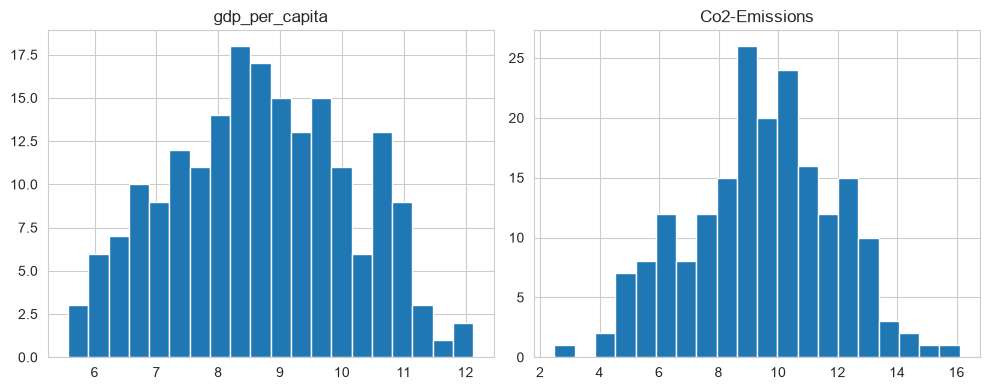

In [17]:
# 2. Transformación log para las variables muy sesgadas (log1p maneja bien valores en 0)
for col in ['gdp_per_capita', 'Co2-Emissions']:
    df_modelo_v2[col] = np.log1p(df_modelo_v2[col])

df_modelo_v2[['gdp_per_capita', 'Co2-Emissions']].hist(figsize=(10, 4), bins=20)
plt.tight_layout()
plt.show()

# Paso 6: Escalado + método del codo

In [19]:
from sklearn.preprocessing import StandardScaler

X = df_modelo_v2[features_finales_v2]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Media después de escalar (debe ser ~0):", X_scaled.mean(axis=0).round(2))
print("Std después de escalar (debe ser ~1):", X_scaled.std(axis=0).round(2))

Media después de escalar (debe ser ~0): [-0. -0. -0. -0. -0. -0.  0. -0.  0.  0. -0.  0.  0.]
Std después de escalar (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


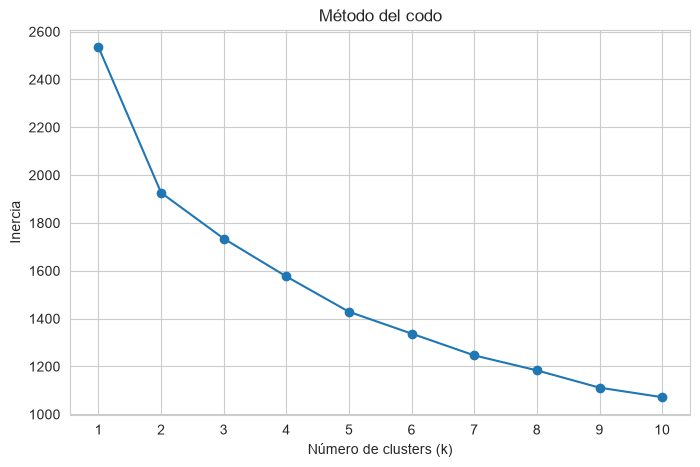

In [20]:
from sklearn.cluster import KMeans

inercias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inercias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.xticks(k_range)
plt.show()

k=2: silhouette=0.2267
k=3: silhouette=0.1521
k=4: silhouette=0.1581
k=5: silhouette=0.1588
k=6: silhouette=0.1577
k=7: silhouette=0.1409
k=8: silhouette=0.1407
k=9: silhouette=0.1461
k=10: silhouette=0.1459


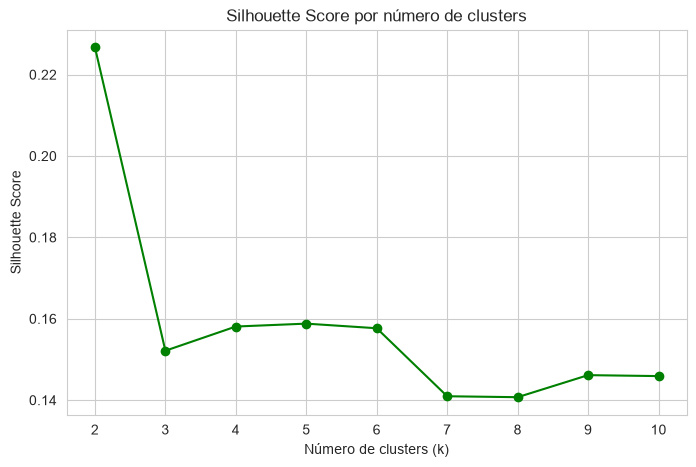

In [21]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.xticks(range(2, 11))
plt.show()

# Paso 7: Comparar perfiles de distintos k

In [22]:
resultados_k = {}

for k in [2, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    df_modelo_v2[f'cluster_k{k}'] = labels
    resultados_k[k] = labels

# Tamaño de cada cluster, para cada k
for k in [2, 4, 5]:
    print(f"\n--- k={k} ---")
    print(df_modelo_v2[f'cluster_k{k}'].value_counts().sort_index())


--- k=2 ---
cluster_k2
0    110
1     85
Name: count, dtype: int64

--- k=4 ---
cluster_k4
0    81
1     2
2    55
3    57
Name: count, dtype: int64

--- k=5 ---
cluster_k5
0    26
1    79
2    42
3     2
4    46
Name: count, dtype: int64


In [23]:
# Perfil promedio de cada cluster, para cada k (en unidades originales, más interpretable)
for k in [2, 4, 5]:
    print(f"\n{'='*60}\nPerfil de clusters (k={k})\n{'='*60}")
    perfil = df_modelo_v2.groupby(f'cluster_k{k}')[features_finales_v2].mean().round(2)
    # Revertimos el log para gdp_per_capita y Co2-Emissions, más legible
    perfil['gdp_per_capita'] = np.expm1(perfil['gdp_per_capita']).round(0)
    perfil['Co2-Emissions'] = np.expm1(perfil['Co2-Emissions']).round(0)
    print(perfil.T)


Perfil de clusters (k=2)
cluster_k2                                      0       1
gdp_per_capita                                inf     inf
urban_pct                                   71.92   41.80
Unemployment rate                            6.81    6.64
Tax revenue (%)                             18.12   14.49
Life expectancy                             77.22   65.98
Physicians per thousand                      2.88    0.47
Out of pocket health expenditure            27.76   38.79
Birth Rate                                  13.21   29.12
Gross primary education enrollment (%)     102.29  102.72
Gross tertiary education enrollment (%)     55.59   14.20
Population: Labor force participation (%)   61.28   64.56
Co2-Emissions                                 inf     inf
Forested Area (%)                           31.99   32.04

Perfil de clusters (k=4)
cluster_k4                                      0       1       2       3
gdp_per_capita                                inf     inf     

c:\Users\uriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [24]:
# Ejemplos de países en cada cluster, para k=4 (el candidato más prometedor) — validación cualitativa
for c in sorted(df_modelo_v2['cluster_k4'].unique()):
    paises = df_modelo_v2[df_modelo_v2['cluster_k4'] == c]['Country'].sample(min(8, (df_modelo_v2['cluster_k4']==c).sum()), random_state=42).tolist()
    print(f"Cluster {c}: {paises}")

Cluster 0: ['Iran', 'Albania', 'Eswatini', 'Jamaica', 'Dominica', 'Honduras', 'Bosnia and Herzegovina', 'Syria']
Cluster 1: ['United States', 'China']
Cluster 2: ['Mali', 'Burundi', 'Mauritania', 'Democratic Republic of the Congo', 'Ghana', 'Turkmenistan', 'Senegal', 'Kenya']
Cluster 3: ['Andorra', 'Belarus', 'Lithuania', 'Czech Republic', 'Monaco', 'United Kingdom', 'Kuwait', 'Luxembourg']


In [25]:
# Guardamos las columnas originales (antes del log) para reportes, en un dataframe aparte
df_reporte = df_modelo_imputado[['Country', 'gdp_per_capita', 'Co2-Emissions']].copy()
df_reporte = df_reporte.rename(columns={'gdp_per_capita': 'gdp_per_capita_real', 'Co2-Emissions': 'co2_real'})

# Unimos con las etiquetas de cluster (ya calculadas correctamente en X_scaled)
df_reporte = df_reporte.merge(df_modelo_v2[['Country', 'cluster_k2', 'cluster_k4', 'cluster_k5']], on='Country')

# Perfil correcto, usando SIEMPRE las columnas reales, sin reversión de log
for k in [2, 4, 5]:
    print(f"\n{'='*60}\nPerfil de clusters (k={k}) — valores reales\n{'='*60}")
    otras_features = [f for f in features_finales_v2 if f not in ['gdp_per_capita', 'Co2-Emissions']]
    
    perfil_otras = df_modelo_v2.groupby(f'cluster_k{k}')[otras_features].mean().round(2)
    perfil_reales = df_reporte.groupby(f'cluster_k{k}')[['gdp_per_capita_real', 'co2_real']].mean().round(0)
    
    perfil_completo = pd.concat([perfil_reales, perfil_otras], axis=1)
    print(perfil_completo.T)


Perfil de clusters (k=2) — valores reales
cluster_k2                                         0         1
gdp_per_capita_real                         25764.00   2426.00
co2_real                                   257100.00  61545.00
urban_pct                                      71.92     41.80
Unemployment rate                               6.81      6.64
Tax revenue (%)                                18.12     14.49
Life expectancy                                77.22     65.98
Physicians per thousand                         2.88      0.47
Out of pocket health expenditure               27.76     38.79
Birth Rate                                     13.21     29.12
Gross primary education enrollment (%)        102.29    102.72
Gross tertiary education enrollment (%)        55.59     14.20
Population: Labor force participation (%)      61.28     64.56
Forested Area (%)                              31.99     32.04

Perfil de clusters (k=4) — valores reales
cluster_k4                      

# Ajuste: quitar CO2 (o usarlo per cápita) y repetir

In [26]:
# Opción: usar CO2 per cápita en vez de total — así no está dominado por el tamaño del país
df_modelo_v2['co2_per_capita'] = df_modelo_imputado['Co2-Emissions'] / df_modelo_imputado['gdp_per_capita'].index.map(
    lambda i: df['Population'].iloc[i]
)
# Más simple y directo: recalculamos desde el df original
df_modelo_v2['co2_per_capita'] = df['Co2-Emissions'] / df['Population']

print(df_modelo_v2[['Country', 'co2_per_capita']].sort_values('co2_per_capita', ascending=False).head(10))

                  Country  co2_per_capita
141                 Qatar        0.036461
177   Trinidad and Tobago        0.031447
90                 Kuwait        0.023469
184  United Arab Emirates        0.021117
12                Bahrain        0.021106
24                 Brunei        0.017688
151          Saudi Arabia        0.016442
186         United States        0.015252
32                 Canada        0.014730
8               Australia        0.014589


In [28]:
# Recalculamos co2_per_capita usando las columnas YA imputadas, no las originales
df_modelo_v2['co2_per_capita'] = df_modelo_imputado['Co2-Emissions'] / df['Population']

# Por si Population también tiene su nulo, imputamos con la mediana al final
df_modelo_v2['co2_per_capita'] = df_modelo_v2['co2_per_capita'].fillna(df_modelo_v2['co2_per_capita'].median())

print("Nulos en co2_per_capita:", df_modelo_v2['co2_per_capita'].isna().sum())
print(df_modelo_v2[['Country', 'co2_per_capita']].sort_values('co2_per_capita', ascending=False).head(10))

Nulos en co2_per_capita: 0
                  Country  co2_per_capita
73           Vatican City       14.716507
120                 Nauru        1.220052
149            San Marino        0.363349
113                Monaco        0.315753
141                 Qatar        0.036461
177   Trinidad and Tobago        0.031447
90                 Kuwait        0.023469
184  United Arab Emirates        0.021117
12                Bahrain        0.021106
24                 Brunei        0.017688


In [29]:
features_finales_v3 = [f for f in features_finales_v2 if f != 'Co2-Emissions'] + ['co2_per_capita']

X_v3 = df_modelo_v2[features_finales_v3].copy()
X_v3['co2_per_capita'] = np.log1p(X_v3['co2_per_capita'])

# Verificación final antes de escalar — no debe haber ningún NaN
print("Nulos totales en X_v3:", X_v3.isna().sum().sum())

X_v3_scaled = StandardScaler().fit_transform(X_v3)

Nulos totales en X_v3: 0


In [30]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_v3_scaled)
    score = silhouette_score(X_v3_scaled, labels)
    print(f"k={k}: silhouette={score:.4f}, tamaños={pd.Series(labels).value_counts().sort_index().to_dict()}")

k=2: silhouette=0.2297, tamaños={0: 110, 1: 85}
k=3: silhouette=0.1545, tamaños={0: 58, 1: 81, 2: 56}
k=4: silhouette=0.1984, tamaños={0: 93, 1: 53, 2: 1, 3: 48}
k=5: silhouette=0.1608, tamaños={0: 56, 1: 35, 2: 76, 3: 27, 4: 1}


In [31]:
# Confirmamos qué países caen en los clusters de tamaño 1
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = km4.fit_predict(X_v3_scaled)
df_modelo_v2['cluster_temp'] = labels4

conteo = df_modelo_v2['cluster_temp'].value_counts()
cluster_pequeño = conteo[conteo == 1].index[0]
print(df_modelo_v2[df_modelo_v2['cluster_temp'] == cluster_pequeño][['Country'] + features_finales_v3])

         Country  gdp_per_capita  urban_pct  Unemployment rate  \
73  Vatican City      5955.10901  59.537996               5.36   

    Tax revenue (%)  Life expectancy  Physicians per thousand  \
73             16.3             73.2                     1.46   

    Out of pocket health expenditure  Birth Rate  \
73                              30.7       17.95   

    Gross primary education enrollment (%)  \
73                                  102.55   

    Gross tertiary education enrollment (%)  \
73                                     31.2   

    Population: Labor force participation (%)  Forested Area (%)  \
73                                      62.45               32.0   

    co2_per_capita  
73       14.716507  


In [32]:
# Revisemos qué tan "micro" son los países más pequeños del dataset por población
print(df[['Country', 'Population']].sort_values('Population').head(10))

                   Country  Population
73            Vatican City       836.0
120                  Nauru     10084.0
181                 Tuvalu     11646.0
132                  Palau     18233.0
149             San Marino     33860.0
98           Liechtenstein     38019.0
113                 Monaco     38964.0
145  Saint Kitts and Nevis     52823.0
107       Marshall Islands     58791.0
48                Dominica     71808.0


In [33]:
# Definimos un umbral razonable de población mínima para incluir en el clustering
poblacion_minima = 100_000  # criterio de dominio: excluye microestados

paises_excluidos = df[df['Population'] < poblacion_minima]['Country'].tolist()
print(f"Países excluidos por población < {poblacion_minima}: {paises_excluidos}")

df_cluster_final = df_modelo_v2[~df_modelo_v2['Country'].isin(paises_excluidos)].copy()
print("Países restantes:", df_cluster_final.shape[0])

Países excluidos por población < 100000: ['Andorra', 'Antigua and Barbuda', 'Dominica', 'Vatican City', 'Liechtenstein', 'Marshall Islands', 'Monaco', 'Nauru', 'Palau', 'Saint Kitts and Nevis', 'San Marino', 'Seychelles', 'Tuvalu']
Países restantes: 182


# Repetimos escalado y elección de k con el dataset depurado

In [34]:
X_final = df_cluster_final[features_finales_v3].copy()

print("Nulos en X_final:", X_final.isna().sum().sum())
print("Shape:", X_final.shape)

X_final_scaled = StandardScaler().fit_transform(X_final)

Nulos en X_final: 0
Shape: (182, 13)


In [35]:
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_final_scaled)
    score = silhouette_score(X_final_scaled, labels)
    tamaños = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f"k={k}: silhouette={score:.4f}, tamaños={tamaños}")

k=2: silhouette=0.2461, tamaños={0: 92, 1: 90}
k=3: silhouette=0.1646, tamaños={0: 75, 1: 54, 2: 53}
k=4: silhouette=0.1716, tamaños={0: 32, 1: 25, 2: 67, 3: 58}
k=5: silhouette=0.1640, tamaños={0: 27, 1: 37, 2: 32, 3: 56, 4: 30}
k=6: silhouette=0.1823, tamaños={0: 7, 1: 19, 2: 21, 3: 61, 4: 38, 5: 36}


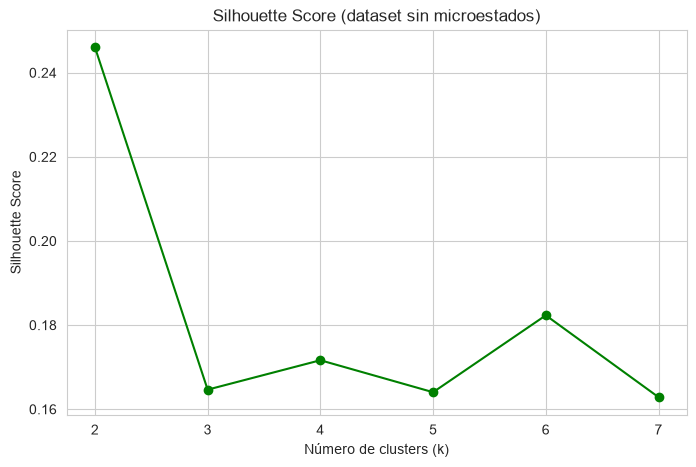

In [36]:
# Gráfica de silhouette para visualizar la comparación completa
scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_final_scaled)
    scores.append(silhouette_score(X_final_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), scores, marker='o', color='green')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (dataset sin microestados)')
plt.xticks(range(2, 8))
plt.show()

# Paso 8: K-Means final con k=4

In [37]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_final['cluster'] = kmeans_final.fit_predict(X_final_scaled)

print(df_cluster_final['cluster'].value_counts().sort_index())

cluster
0    32
1    25
2    67
3    58
Name: count, dtype: int64


In [38]:
# Perfil interpretable de cada cluster (valores reales, sin log)
otras_features = [f for f in features_finales_v3 if f not in ['gdp_per_capita', 'co2_per_capita']]

perfil_otras = df_cluster_final.groupby('cluster')[otras_features].mean().round(2)
perfil_reales = df.set_index('Country').loc[df_cluster_final['Country'], ['Population']].reset_index()
perfil_reales['cluster'] = df_cluster_final['cluster'].values

# gdp_per_capita y co2_per_capita ya están en escala log en df_cluster_final — usamos las columnas originales
gdp_real = df_cluster_final[['Country', 'cluster']].merge(
    df_modelo_imputado[['Country', 'gdp_per_capita']], on='Country'
).groupby('cluster')['gdp_per_capita'].mean().round(0)

co2_real = df_cluster_final[['Country', 'cluster']].merge(
    df_cluster_final[['Country']].assign(co2pc=np.expm1(df_cluster_final['co2_per_capita'])), on='Country'
).groupby('cluster')['co2pc'].mean().round(2)

perfil_completo = perfil_otras.copy()
perfil_completo.insert(0, 'gdp_per_capita_real', gdp_real)
perfil_completo.insert(1, 'co2_per_capita_real', co2_real)

print(perfil_completo.T)

cluster                                           0        1         2  \
gdp_per_capita_real                        48311.00  2024.00  11204.00   
co2_per_capita_real                            0.01     0.00      0.00   
urban_pct                                     83.68    41.04     67.28   
Unemployment rate                              4.52     7.83      8.68   
Tax revenue (%)                               17.45    11.66     18.40   
Life expectancy                               80.48    64.86     75.91   
Physicians per thousand                        3.23     0.59      2.74   
Out of pocket health expenditure              17.21    59.45     33.75   
Birth Rate                                    11.60    31.45     14.04   
Gross primary education enrollment (%)       102.38    87.50    101.73   
Gross tertiary education enrollment (%)       65.39    14.87     54.05   
Population: Labor force participation (%)     65.18    55.17     59.37   
Forested Area (%)                     

In [39]:
# Ejemplos de países por cluster, para validación cualitativa
for c in sorted(df_cluster_final['cluster'].unique()):
    paises = df_cluster_final[df_cluster_final['cluster'] == c]['Country'].sample(
        min(8, (df_cluster_final['cluster']==c).sum()), random_state=42
    ).tolist()
    n_total = (df_cluster_final['cluster']==c).sum()
    print(f"Cluster {c} (n={n_total}): {paises}")

Cluster 0 (n=32): ['United Arab Emirates', 'Japan', 'Singapore', 'Luxembourg', 'Estonia', 'Finland', 'United Kingdom', 'South Korea']
Cluster 1 (n=25): ['Guinea', 'Pakistan', 'Afghanistan', 'Turkmenistan', 'Kyrgyzstan', 'India', 'Mauritania', 'Bangladesh']
Cluster 2 (n=67): ['Malaysia', 'Croatia', 'Azerbaijan', 'Brazil', 'North Korea', 'Mexico', 'Thailand', 'The Bahamas']
Cluster 3 (n=58): ['Angola', 'Botswana', 'Myanmar', 'Democratic Republic of the Congo', 'Sierra Leone', 'Uganda', 'Nicaragua', 'Kenya']


# Paso 9: Visualización con PCA

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final_scaled)

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total explicada por 2 componentes: {sum(pca.explained_variance_ratio_):.2%}")

Varianza explicada: PC1=37.84%, PC2=13.62%
Varianza total explicada por 2 componentes: 51.46%


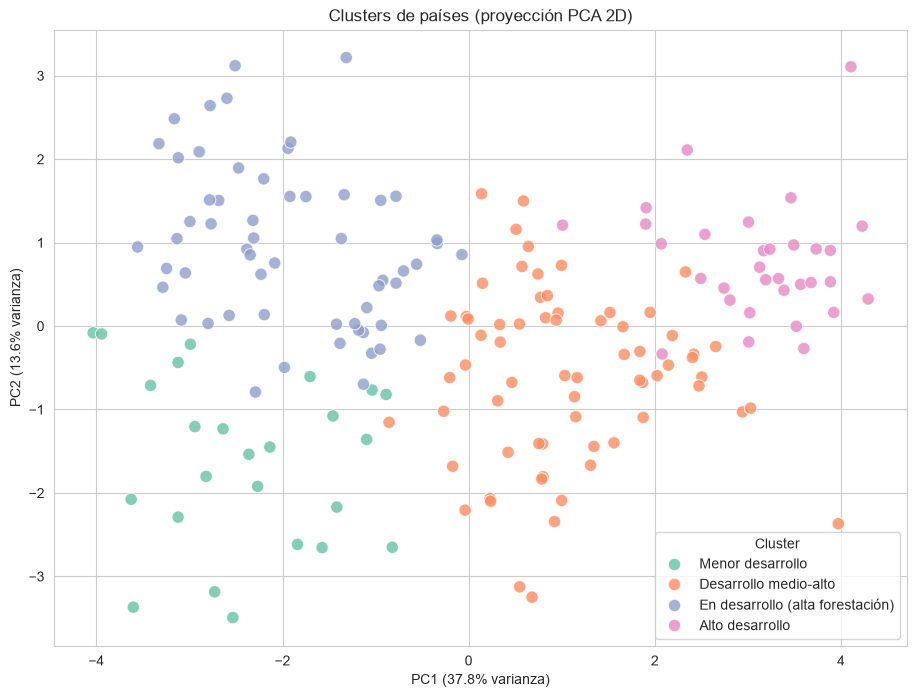

In [41]:
df_cluster_final['pca1'] = X_pca[:, 0]
df_cluster_final['pca2'] = X_pca[:, 1]

nombres_cluster = {0: 'Alto desarrollo', 1: 'Menor desarrollo', 2: 'Desarrollo medio-alto', 3: 'En desarrollo (alta forestación)'}
df_cluster_final['cluster_nombre'] = df_cluster_final['cluster'].map(nombres_cluster)

plt.figure(figsize=(11, 8))
sns.scatterplot(data=df_cluster_final, x='pca1', y='pca2', hue='cluster_nombre', palette='Set2', s=80, alpha=0.8)
plt.title('Clusters de países (proyección PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.legend(title='Cluster')
plt.show()

# Paso 10: Clustering jerárquico (validación adicional)

C:\Users\uriel\AppData\Local\Temp\ipykernel_31284\3954185398.py:13: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\uriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


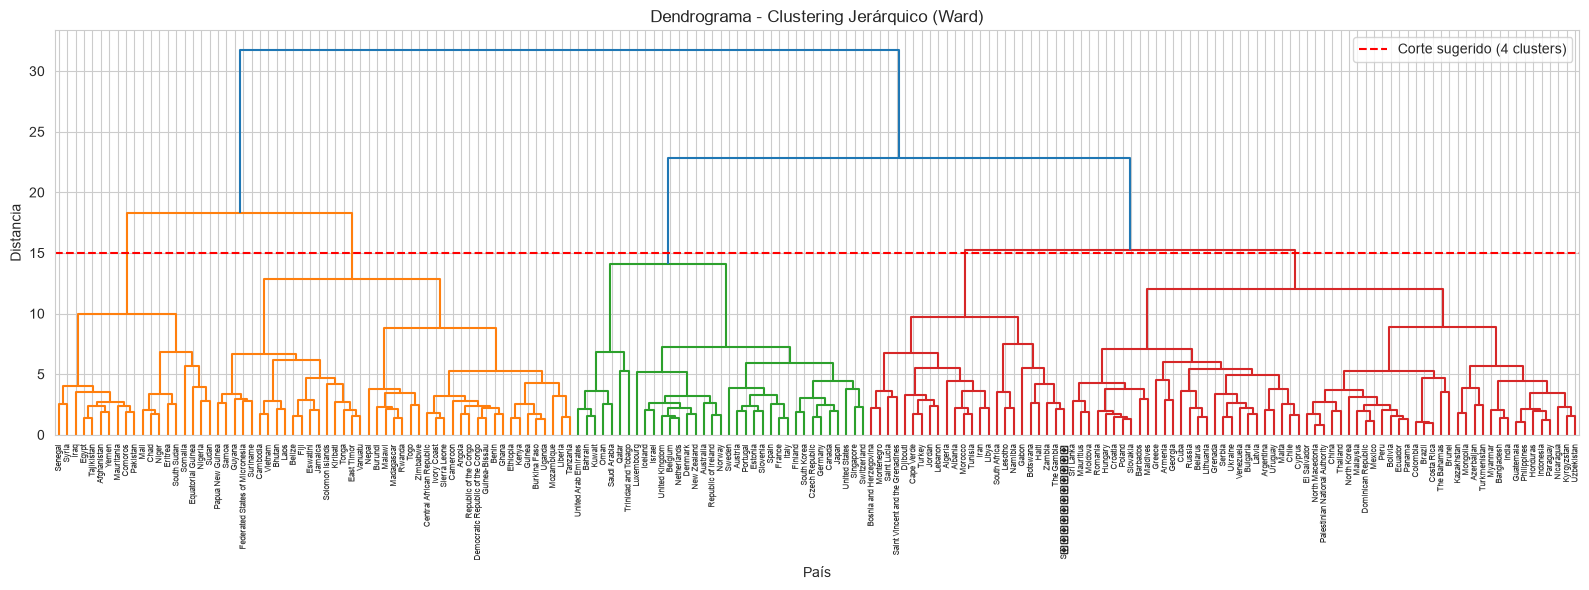

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Usamos el método Ward, que minimiza la varianza dentro de cada cluster (compatible con el enfoque de K-Means)
Z = linkage(X_final_scaled, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(Z, labels=df_cluster_final['Country'].values, leaf_rotation=90, leaf_font_size=6)
plt.title('Dendrograma - Clustering Jerárquico (Ward)')
plt.xlabel('País')
plt.ylabel('Distancia')
plt.axhline(y=15, color='r', linestyle='--', label='Corte sugerido (4 clusters)')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Cortamos el dendrograma en 4 clusters, igual que K-Means, para comparar directamente
clusters_jerarquico = fcluster(Z, t=4, criterion='maxclust')
df_cluster_final['cluster_jerarquico'] = clusters_jerarquico

# Tabla de contingencia: ¿qué tanto coinciden K-Means y Jerárquico?
tabla_comparacion = pd.crosstab(df_cluster_final['cluster'], df_cluster_final['cluster_jerarquico'])
print(tabla_comparacion)

cluster_jerarquico   1   2   3   4
cluster                           
0                    0   0  31   1
1                   19   1   0   5
2                    0   2   4  61
3                    0  40   0  18


In [44]:
from sklearn.metrics import adjusted_rand_score

# Índice de Rand ajustado: mide qué tanto coinciden dos particiones (1.0 = idénticas, 0 = aleatorio)
ari = adjusted_rand_score(df_cluster_final['cluster'], df_cluster_final['cluster_jerarquico'])
print(f"Adjusted Rand Index (K-Means vs Jerárquico): {ari:.4f}")

Adjusted Rand Index (K-Means vs Jerárquico): 0.5577


## Conclusiones

Este proyecto segmenta 195 países por indicadores socioeconómicos y de salud (dataset 
Global Country Information 2023), con un enfoque inspirado en el caso real de HELP 
International: identificar qué países podrían necesitar más apoyo humanitario según 
su nivel de desarrollo.

### Hallazgos principales

**1. Cuatro perfiles de desarrollo claramente diferenciados**
K-Means con k=4 (elegido tras comparar k=2 a k=6 por silhouette score y tamaño de 
clusters) identificó:
- **Alto desarrollo** (32 países: UAE, Japón, Singapur, Finlandia): GDP per cápita 
  $48,311, esperanza de vida 80.5 años, 3.23 médicos/mil habitantes.
- **Desarrollo medio-alto** (67 países: Malasia, Brasil, México, Tailandia): GDP 
  per cápita $11,204, esperanza de vida 75.9 años.
- **En desarrollo, alta forestación** (58 países: Angola, Kenia, RD Congo, Myanmar): 
  GDP per cápita $2,433, alta cobertura forestal (41.8% vs 11.4% del grupo 
  siguiente).
- **Menor desarrollo** (25 países: Afganistán, Pakistán, Guinea, Bangladesh): GDP 
  per cápita $2,024, esperanza de vida 64.9 años, solo 0.42 médicos/mil habitantes 
  — el grupo con indicadores de salud más críticos.

**2. Los microestados requieren tratamiento especial en clustering socioeconómico**
13 países con población menor a 100,000 (Vaticano, Nauru, San Marino, entre otros) 
fueron excluidos tras detectar que sus métricas "per cápita" (especialmente 
CO2 per cápita) se distorsionaban por poblaciones extremadamente pequeñas, generando 
clusters de 1-2 países que no reflejaban patrones reales de desarrollo.

**3. El "desarrollo" es un continuo, no categorías discretas**
La validación cruzada con clustering jerárquico (Ward) mostró alta concordancia 
en los extremos del espectro (Alto desarrollo y Menor desarrollo, >95% de coincidencia), 
pero discrepancia notable en la frontera entre los dos grupos intermedios (Adjusted 
Rand Index de 0.558 entre ambos métodos) — el desarrollo socioeconómico no tiene 
fronteras nítidas entre niveles medios.

**4. Existen al menos dos perfiles distintos de "bajo desarrollo"**
Contrario a agrupar todos los países pobres en un solo cluster, el modelo distinguió 
entre países de bajo ingreso con alta cobertura forestal (África subsahariana) 
y países de bajo ingreso con indicadores de salud más críticos y menor cobertura 
forestal (Asia central/sur) — un matiz que un análisis binario "desarrollado vs. 
no desarrollado" (k=2) habría ocultado por completo.

### Consideraciones metodológicas
- Limpieza extensa de formato: 26 de 35 columnas venían como texto con símbolos 
  ($, %, comas) y requirieron conversión sistemática.
- Imputación con mediana para columnas con hasta 23% de nulos, tras confirmar que 
  eliminar filas incompletas introduciría sesgo hacia excluir países menos 
  desarrollados (con menor capacidad estadística de reporte).
- Reducción de redundancia: se descartaron `Infant mortality` y `Fertility Rate` 
  por correlación >0.85 con otras variables del modelo.
- Transformación logarítmica en variables sesgadas (`gdp_per_capita`, emisiones de 
  CO2) antes del escalado.
- Uso de CO2 per cápita en vez de CO2 total, para evitar que el tamaño poblacional 
  del país dominara el agrupamiento por encima del desarrollo per cápita real.

### Posibles siguientes pasos
- Incorporar series de tiempo (varios años) para analizar trayectorias de desarrollo, 
  no solo una fotografía estática.
- Clustering geográfico complementario (¿los clusters se agrupan también por región?).
- Análisis de sensibilidad probando distintas combinaciones de features para verificar 
  la estabilidad de los 4 clusters ante cambios en las variables de entrada.